In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer
import pandas as pd
import numpy as np
import lime.lime_text
import gensim.downloader as api

In [2]:
# Load the dataset
train_path = "train.csv" 
test_path = "valid.csv"

# Attempt different encodings if UTF-8 fails
encodings = ["utf-8", "ISO-8859-1", "latin1"]

for enc in encodings:
    try:
        train_df = pd.read_csv(train_path, encoding=enc)
        test_df = pd.read_csv(test_path, encoding=enc)
        print(f"Successfully loaded with encoding: {enc}")
        break  # Stop if successful
    except UnicodeDecodeError:
        print(f"Encoding {enc} failed, trying next...")

Successfully loaded with encoding: utf-8


In [3]:
print(train_df.shape)
train_df.head()

(120000, 3)


,answers,query,finalpassage
0,"Kids who are bipolar, in their manic stages, v...",why do children get aggressive,"At the same time, despite claiming the review ..."
1,"Equifax, transunion and experian.",which credit bureau is used the most for auto ...,Best Answer: both of those answers are wrong. ...
2,"Women eat at least 1,200 calories daily and me...",what is the minimum healthy calorie intake,Safe Intakes. If you’re not supervised by a me...
3,Because Caffeine increases the stress hormone ...,why is coffee making gain weight,Is coffee making you fat? If you are overweigh...
4,Kent County,"what county is grand rapids, mi in","Located in Grand Rapids, Michigan, the 61st Di..."


In [4]:
print(test_df.shape)
test_df.head()

(10585, 3)


,answers,query,finalpassage
0,It is a very popular first name for men and al...,how popular is the name conrad,The name Conrad is a baby boy name. The name C...
1,No worries,disney hakuna matata meaning,Hakuna Matata (song) Hakuna Matata is a song f...
2,Electronic medical recordElectronic Medical Re...,what does emr stand for,The EMR (electronic medical record) is used to...
3,It is the skin around its neck.,what is a dog's ruff,"No problem! Many dogs, like many people, are j..."
4,On the inner surface of your arm near your elbow.,what is the part on your arm where they draw b...,"One, called venipuncture, involves drawing a v..."


In [5]:
print(train_df.isnull().sum())
train_df.dropna(inplace=True)
print(train_df.isnull().sum())

answers         55
query            0
finalpassage    24
dtype: int64
answers         0
query           0
finalpassage    0
dtype: int64


In [6]:
print(test_df.isnull().sum())
test_df.dropna(inplace=True)
print(test_df.isnull().sum())

answers         4
query           0
finalpassage    1
dtype: int64
answers         0
query           0
finalpassage    0
dtype: int64


In [7]:
one_row = train_df.iloc[0]

print("Query: ", one_row["query"])
print("Answer: ", one_row["answers"])
print("Final Passage: ", one_row["finalpassage"])

Query:  why do children get aggressive
Answer:  Kids who are bipolar, in their manic stages, very frequently become aggressive. They lose self-control, they become impulsive. On the other end of the spectrum, when they become depressed, although aggression is less common, they can become irritable, and sometimes that irritability and cantankerousness causes kids to lash out.
Final Passage:  At the same time, despite claiming the review demonstrates a link between playing violent video games and aggression, the authors acknowledged that some studies were inconsistent and that present research is insufficient to establish whether this can lead to criminal violence or delinquency.Kids who are bipolar, in their manic stages, very frequently become aggressive. They lose self-control, they become impulsive. On the other end of the spectrum, when they become depressed, although aggression is less common, they can become irritable, and sometimes that irritability and cantankerousness causes ki

In [8]:
train_df.drop("finalpassage", axis=1, inplace = True)

In [9]:
test_df.drop("finalpassage", axis=1, inplace = True)

In [10]:
import re
def remove_special_chars(text):
    return re.sub(r'[^a-zA-Z0-9\s.,?!]', '', text)

train_df["query"] = train_df["query"].apply(remove_special_chars)
train_df["answers"] = train_df["answers"].apply(remove_special_chars)

test_df["query"] = test_df["query"].apply(remove_special_chars)
test_df["answers"] = test_df["answers"].apply(remove_special_chars)

In [11]:
def remove_emojis_and_mentions(text):
    # Remove mentions, hashtags, and URLs
    text = re.sub(r'@[\w]+', ' ', text)  # Remove mentions
    text = re.sub(r'http\S+|www\S+', ' ', text)  # Remove URLs
    text = re.sub(r'[^\x00-\x7F]+', '', text)  # Remove emojis
    return text

train_df["query"] = train_df["query"].apply(remove_emojis_and_mentions)
train_df["answers"] = train_df["answers"].apply(remove_emojis_and_mentions)

test_df["query"] = test_df["query"].apply(remove_emojis_and_mentions)
test_df["answers"] = test_df["answers"].apply(remove_emojis_and_mentions)

In [12]:
train_df["query"] = train_df["query"].str.lower()
train_df["answers"] = train_df["answers"].str.lower()

test_df["query"] = test_df["query"].str.lower()
test_df["answers"] = test_df["answers"].str.lower()

In [13]:
# Load Word2Vec pretrained embeddings
word2vec = api.load("word2vec-google-news-300")
embed_dim = word2vec.vector_size

In [14]:
word2vec.save("word2vec-google-news-300.model")

In [15]:
# Tokenizer Setup
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
max_len = 128

train_df["query_tokens"] = train_df["query"].apply(lambda x: tokenizer.encode_plus(x, max_length=max_len, padding="max_length", truncation=True, return_tensors='pt'))
train_df["answer_tokens"] = train_df["answers"].apply(lambda x: tokenizer.encode_plus(x, max_length=max_len, padding="max_length", truncation=True, return_tensors='pt'))
test_df["query_tokens"] = test_df["query"].apply(lambda x: tokenizer.encode_plus(x, max_length=max_len, padding="max_length", truncation=True, return_tensors='pt'))
test_df["answer_tokens"] = test_df["answers"].apply(lambda x: tokenizer.encode_plus(x, max_length=max_len, padding="max_length", truncation=True, return_tensors='pt'))

In [16]:
def tokens_to_word2vec(tokens):
    vectors = [word2vec[word] if word in word2vec else np.zeros(embed_dim) for word in tokens]
    return np.array(vectors, dtype=np.float32)

# Convert train tokens to embeddings
train_df["query_embeddings"] = train_df["query_tokens"].apply(tokens_to_word2vec)
train_df["answer_embeddings"] = train_df["answer_tokens"].apply(tokens_to_word2vec)

# Convert test tokens to embeddings
test_df["query_embeddings"] = test_df["query_tokens"].apply(tokens_to_word2vec)
test_df["answer_embeddings"] = test_df["answer_tokens"].apply(tokens_to_word2vec)

In [17]:
class ChatDataset(Dataset):
    def __init__(self, queries, answers):
        self.queries = queries
        self.answers = answers

    def __len__(self):
        return len(self.queries)

    def __getitem__(self, idx):
        return torch.tensor(self.queries[idx]), torch.tensor(self.answers[idx])

In [18]:
# Sample
train_subset = train_df.sample(frac=0.7, random_state=42).reset_index(drop=True)  # 70% of train_df

# Prepare Data
train_dataset = ChatDataset(train_subset["query_embeddings"].tolist(), train_df["answer_embeddings"].tolist())
test_dataset = ChatDataset(test_df["query_embeddings"].tolist(), test_df["answer_embeddings"].tolist())

#Load Data
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [19]:
from tqdm import tqdm

# --- Model ---
class CausalTransformer(nn.Module):
    def __init__(self, d_model=300, nhead=6, num_layers=6, dim_feedforward=512, max_len=128):
        super().__init__()
        self.pos_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            activation='gelu'
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        self.fc_out = nn.Linear(d_model, d_model)

    def forward(self, x, pos_ids):
        x = x + self.pos_embedding(pos_ids)

        seq_len = x.size(1)
        mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool().to(x.device)

        x = x.transpose(0, 1)  # (seq_len, batch, d_model)

        memory = self.encoder(x, mask=mask)
        output = self.decoder(x, memory, tgt_mask=mask, memory_mask=mask)
        output = output.transpose(0, 1)  # (batch, seq_len, d_model)

        return self.fc_out(output)

In [20]:
import torch
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt
import json
from tqdm import tqdm

# Assuming the CausalTransformer model and train_loader are already defined

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = CausalTransformer().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 2

# List to store the loss per batch
batch_losses = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    for batch_idx, (query_emb, answer_emb) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
        query_emb = query_emb.to(device)
        answer_emb = answer_emb.to(device)

        batch_size, seq_len, _ = query_emb.size()
        pos_ids = torch.arange(seq_len).unsqueeze(0).repeat(batch_size, 1).to(device)

        output = model(query_emb, pos_ids)

        if output.size(1) != answer_emb.size(1):
            output = output[:, :answer_emb.size(1), :]

        loss = criterion(output, answer_emb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        batch_losses.append(loss.item())  # Store loss per batch

        # Optionally print loss every 10000 batches
        if batch_idx % 10000 == 0:
            print(f"[Batch {batch_idx}] Loss: {loss.item():.4f}")

    avg_epoch_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_epoch_loss:.4f}")

Using device: cuda


C:\Users\chetn\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
Epoch 1:   0%|                                                                       | 3/10494 [00:00<46:54,  3.73it/s]

[Batch 0] Loss: 0.3388


Epoch 1:  95%|███████████████████████████████████████████████████████████████▊   | 10004/10494 [08:22<00:24, 19.97it/s]

[Batch 10000] Loss: 0.0000


...

[Batch 0] Loss: 0.0000


Epoch 2:  95%|███████████████████████████████████████████████████████████████▉   | 10005/10494 [08:44<00:25, 19.52it/s]

[Batch 10000] Loss: 0.0000


Epoch 2: 100%|███████████████████████████████████████████████████████████████████| 10494/10494 [09:10<00:00, 19.05it/s]

Epoch 2/2 - Loss: 0.0000


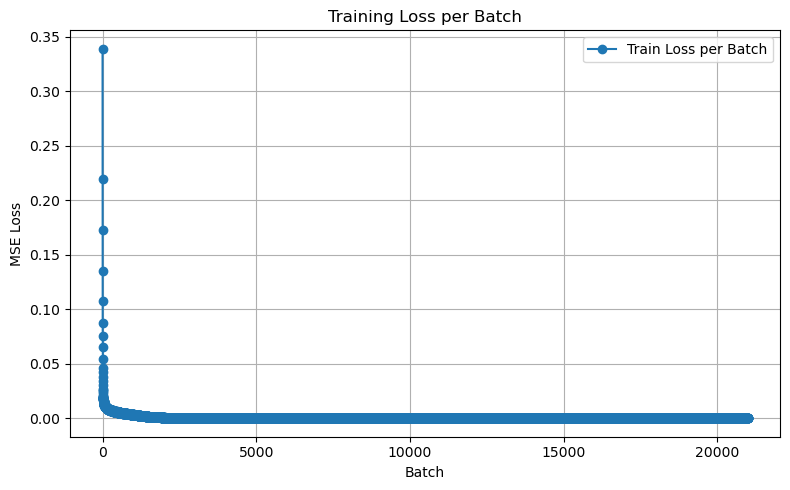

In [21]:
# Save batch losses to a file (JSON)
with open('batch_losses.json', 'w') as f:
    json.dump(batch_losses, f)

# Plotting the training loss per batch
plt.figure(figsize=(8, 5))
plt.plot(batch_losses, marker='o', label="Train Loss per Batch")
plt.title("Training Loss per Batch")
plt.xlabel("Batch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# Save full model (architecture + weights)
torch.save(model, "causal_transformer_full_2.pth")
model

CausalTransformer(
  (pos_embedding): Embedding(128, 300)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=300, out_features=300, bias=True)
        )
        (linear1): Linear(in_features=300, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=300, bias=True)
        (norm1): LayerNorm((300,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((300,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=300, out_features=300, bias=T

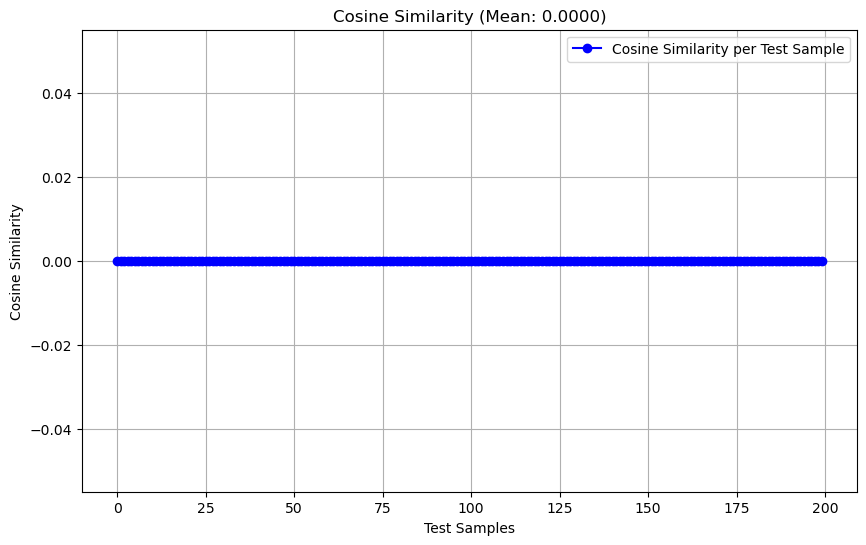

Average Cosine Similarity: 0.0000


In [63]:
import torch
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

def evaluate_cosine_similarity(model, test_loader, device, subset_size=5000):
    model.eval()
    predictions, references = [], []

    with torch.no_grad():
        # Iterate through the test set (subset_size)
        for batch_idx, (query, answer) in enumerate(test_loader):
            if batch_idx * test_loader.batch_size >= subset_size:
                break

            query = query.to(device).float()
            answer = answer.to(device).float()
            pos_ids = torch.zeros(query.size(0), query.size(1), dtype=torch.long).to(device)

            # Get model output (generated answer embeddings)
            output = model(query, pos_ids)

            # Store generated answer embeddings (predictions) and ground truth answer embeddings
            for i in range(output.size(0)):
                pred_emb = output[i].cpu().numpy()  # Generated answer embedding (predicted by model)
                ref_emb = answer[i].cpu().numpy()  # Ground truth answer embedding

                # Average the embeddings to represent the entire sequence
                pred_avg = pred_emb.mean(axis=0)
                ref_avg = ref_emb.mean(axis=0)
                
                predictions.append(pred_avg)  # Store predicted embeddings
                references.append(ref_avg)  # Store ground-truth embeddings

    # Convert lists to numpy arrays for similarity computation
    pred_embeddings = np.array(predictions)
    ref_embeddings = np.array(references)

    # Compute cosine similarity between predicted and reference embeddings
    similarities = cosine_similarity(pred_embeddings, ref_embeddings)

    # Calculate the average cosine similarity across the evaluated subset
    avg_cos_sim = np.mean(similarities)

    # Plot similarity values for each test sample
    plt.figure(figsize=(10, 6))
    plt.plot(np.diag(similarities), label="Cosine Similarity per Test Sample", color='b', marker='o')
    plt.title(f"Cosine Similarity (Mean: {avg_cos_sim:.4f})")
    plt.xlabel('Test Samples')
    plt.ylabel('Cosine Similarity')
    plt.grid(True)
    plt.legend()
    plt.show()

    return avg_cos_sim

# Example: Running the evaluation function on a subset of the test data (200 samples)
avg_cos_sim = evaluate_cosine_similarity(model, test_loader, device, subset_size=200)

print(f"Average Cosine Similarity: {avg_cos_sim:.4f}")

In [ ]:
import lime
import torch
from transformers import AutoTokenizer

# Assuming max_len is defined elsewhere and device is set (GPU or CPU)
max_len = 300  # Set the sequence length to 300, as expected by the model

# Load the model from the saved file
model = torch.load("causal_transformer_full_2.pth")
model.eval()  # Set the model to evaluation mode
model.to(device)  # Move the model to the appropriate device (CPU/GPU)

# Load tokenizer (adjust to your specific model)
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')  # Adjust as per your model

# LIME Explainer setup
explainer = lime.lime_text.LimeTextExplainer(class_names=["Negative", "Positive"])

# Define the prediction function for LIME
def predict_fn(texts):
    # Tokenize the input texts with padding to max_len and truncation
    tokenized = tokenizer(texts, return_tensors="pt", padding='max_length', truncation=True, max_length=max_len)
    tokens = tokenized["input_ids"].to(device)
    
    # Check if the tokenized input size matches the expected model input size
    seq_len = tokens.size(1)  # Sequence length of the tokenized input
    print(f"Tokenized input shape: {tokens.shape}")  # Debugging print

    # Generate positional embeddings (ensure it matches the sequence length)
    pos_ids = torch.arange(seq_len, dtype=torch.long).unsqueeze(0).expand(tokens.size(0), -1).to(device)
    print(f"Positional embeddings shape: {pos_ids.shape}")  # Debugging print
    
    # Ensure the model gets the correct inputs (query and positional encodings)
    with torch.no_grad():
        # Pass through the model
        output = model(tokens, pos_ids)  # Adjust if model input structure differs

        # Assuming you want to get logits for classification (adjust layer/structure based on your model)
        logits = output[:, -1, :]  # Typically for causal models, we use the last token's output logits
        
        # Apply softmax to get probabilities (if classification task)
        probs = torch.softmax(logits, dim=-1).cpu().detach().numpy()

    return probs  # LIME needs probabilities, not logits

# Explaining a sample query
exp = explainer.explain_instance("This is a test query", predict_fn, num_features=10)

# Show the explanation in the notebook
exp.show_in_notebook()

| Tasks and Comments | Status |
|--------------------|--------|
| Preprocessing Steps - Cleaning, Tokenization, Formatting | Done |
| Training - Model built with positional embeddings and masked transformer layers | Done |
| Evaluation - Cosine Similarity | Done |
| Final AUC value and plot | N/A (Not Applicable Here) |
| Interpretation using Lime | Pending |
| Next steps Recommended | Pending |